In [2]:
# import relevant libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import os
import string
import pyarrow as pa
import pyarrow.parquet as pq
import fastparquet

In [3]:
# import the cleaned dataset
tracks_df = pd.read_parquet('tracks_df2.parquet', engine='fastparquet')

The next step is to decide what techniques to run on this dataset to try and predict popularity. It would be good to do some regression, and try some other approaches too. This workbook will have the reasoning behind selecting different approaches and then the data preparation to properly use those approaches.

Going to try a Random Forests approach first. Justification
 - The dataset has a lot of categorical features and also has numeric features that are on different scales.
 - no need to meet all the assumptions that are inherent to MLR

In [17]:
# Step 1  - Preprocess the dataframe

# drop columns that I'm not going to use in modeling
df_rf = tracks_df.drop(['track_id', 'artists', 'album_name', 'track_name',
                 'artist_alnum', 'album_alnum', 'track_alnum', 'key', 'mode_exp', 'key_exp_all',
                 'time_signature', 'duration_ms', 'duration_min', 'duration_min_rnd0',
                 'danceability_rnd', 'energy_rnd', 'loudness_rnd', 'speechiness_rnd',
                 'acousticness_rnd', 'liveness_rnd', 'valence_rnd', 'tempo_rnd']
                ,  axis = 1)

In [18]:

df_rf.info()
df_rf.sample(n = 10).to_excel('test.xlsx')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89740 entries, 0 to 89739
Columns: 129 entries, popularity to world_music
dtypes: Int64(1), boolean(116), float64(11), object(1)
memory usage: 28.8+ MB


In [23]:
# just need to encode the key exp field
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_rf['key_exp'] = le.fit_transform(df_rf['key_exp'])

In [ ]:
# check that it worked
print(df_rf['key_exp'].head())

0    11
1     3
2     8
3     3
4     9
Name: key_exp, dtype: int64


In [25]:
# Step 2 - split into training and test datasets
from sklearn.model_selection import train_test_split

X = df_rf.drop(columns=['popularity'])  # All features
y = df_rf['popularity']  # Your 0-100 target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Step 3 - train the random forest
from sklearn.ensemble import RandomForestRegressor

# Create the forest 
rf_model = RandomForestRegressor(
    n_estimators=100,  # Number of trees in the forest
    random_state=42,   # For reproducible results
    n_jobs=-1          # Use all computer cores
)

# Train it
rf_model.fit(X_train, y_train)  

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [28]:
# make predictions

# Predict on test data
predictions = rf_model.predict(X_test)


In [29]:
print(predictions)

[24.31666667 41.05       34.23333333 ... 49.22       44.045
 33.25666026]


In [34]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})
print(results.head(20))

       Actual  Predicted
56975      33  24.316667
84350      43  41.050000
18425      20  34.233333
61780      41  41.730000
85825      46  39.540000
46771       0   1.760000
82070      19  36.510000
66350      27  30.100000
71752      20  22.890571
78611      41  49.254000
57984      37  45.060000
72558      67  37.317500
56678      51  45.430000
40803      73  65.053333
33903      68  57.850000
63093      80  35.455000
64580      26  36.360000
53712      32  20.347333
60681      35  38.062000
46155      39  38.691667


In [32]:
print(comparison)

       explicit  key_exp   mode  duration_min_rnd  danceability  energy  \
0         False      8.0   True               3.9         0.728   0.866   
1         False      4.0   True               7.3         0.483   0.986   
2         False      8.0  False               4.8         0.630   0.868   
3         False      8.0  False               4.6         0.504   0.504   
4         False     10.0   True               4.3         0.167   0.125   
...         ...      ...    ...               ...           ...     ...   
88368      <NA>      NaN   <NA>               NaN           NaN     NaN   
81555      <NA>      NaN   <NA>               NaN           NaN     NaN   
29106      <NA>      NaN   <NA>               NaN           NaN     NaN   
69977      <NA>      NaN   <NA>               NaN           NaN     NaN   
79476      <NA>      NaN   <NA>               NaN           NaN     NaN   

       loudness  speechiness  acousticness  instrumentalness  ...  swedish  \
0        -6.023      

Top 10 Most Important Features:
             feature  importance
8       acousticness    0.057125
6           loudness    0.057069
4       danceability    0.054207
12           valence    0.052874
7        speechiness    0.052541
5             energy    0.052017
13             tempo    0.051743
11          liveness    0.047485
3   duration_min_rnd    0.046701
9   instrumentalness    0.034664


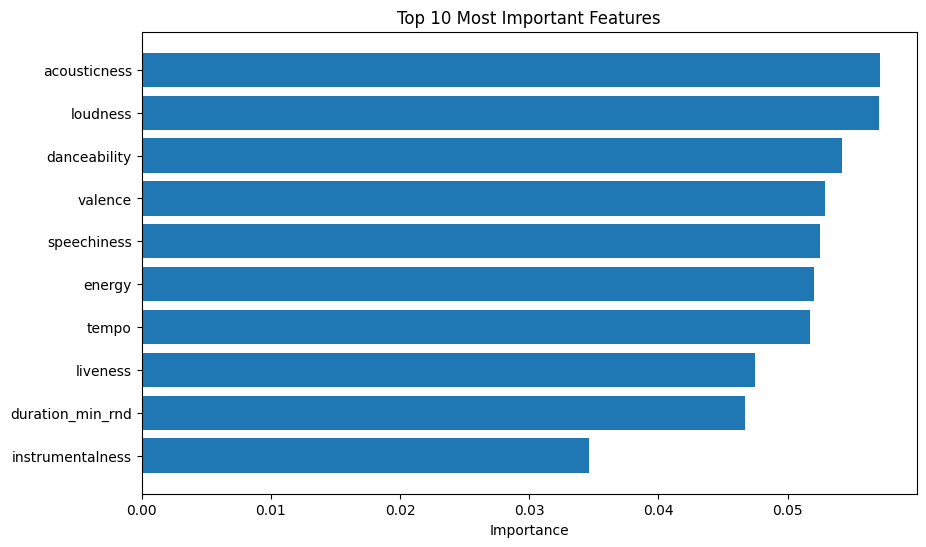

In [30]:
# see what the most important features are
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['feature'], 
         feature_importance.head(10)['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()  # Most important on top
plt.show()